# Modern Portfolio Theory and Geometric Efficient Frontier
The premise of the Modern Portfolio Theory is simple: find a portfolio that balances the risk and return to align with the investors risk tolerance. The founder of this theory, economist Harry Markowitz, suggests that the diversification of assets in a portfolio will produce more predictable returns, supporting the foundation of the MPT. This project sets out to engineer a portfolio with the highest risk-adjusted return from a small group of diverse assets.

[*********************100%***********************]  5 of 5 completed


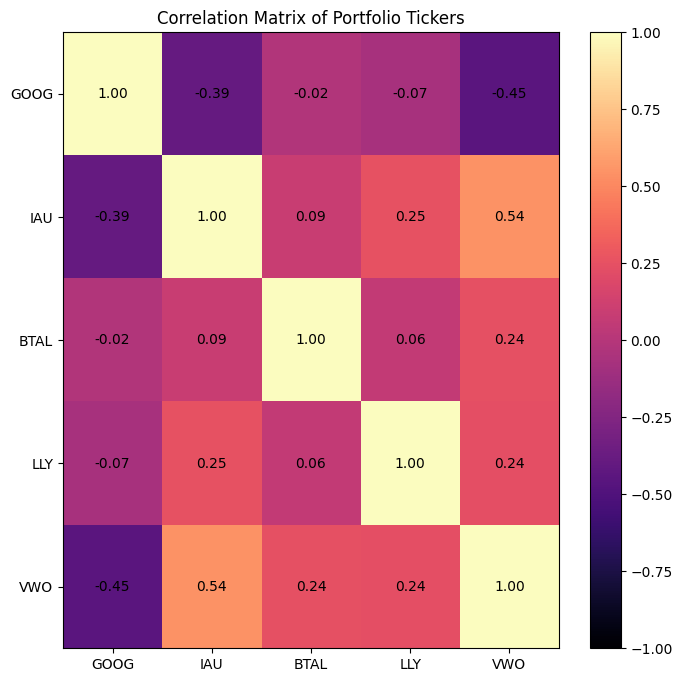

In [23]:
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# get data
tickers = [ "GOOG", # Tech
            "IAU", # Gold Bullion ETF
            "BTAL", # U.S. Anti-Beta Fund; long low-vol, short high-vol
            "LLY", # Health-care
            "VWO" # Emerging Markets ETF
          ]
df = yf.download(tickers, period="10y")["Close"]

# asset returns
daily_log_returns = np.log(df / df.shift(1)).dropna()
annualized_log_returns = daily_log_returns.mean() * 252


# calculate covariance matrix
cov_matrix = daily_log_returns.corr()

# plot
plt.figure(figsize=(8,8))
plt.imshow(cov_matrix, cmap="magma", aspect="auto", vmin=-1, vmax=1)
plt.colorbar()

for i in range(len(cov_matrix)):
    for j in range(len(cov_matrix)):
        plt.text(i, j, f"{cov_matrix.iloc[i, j]:.2f}", ha="center", va="center")

plt.xticks(range(len(cov_matrix)), tickers)
plt.yticks(range(len(cov_matrix)), tickers)
plt.title("Correlation Matrix of Portfolio Tickers")

plt.show()

In statistics, given a correlation $r$, a value of $0 \leq r \leq 0.25$ shows no relationship, and a value of $0.25 < r \leq 0.5$ shows a weak relationship. Since every r in our group shows either a weak or no relationship, we shall conclude that we have found a well diversified portfolio.

Now, let us observe the Efficient Frontier, a tool that is paramount to Modern Portfolio Theory. It is the X and Y Graph of the Risk and Return for thousands of simulated portfolios. 

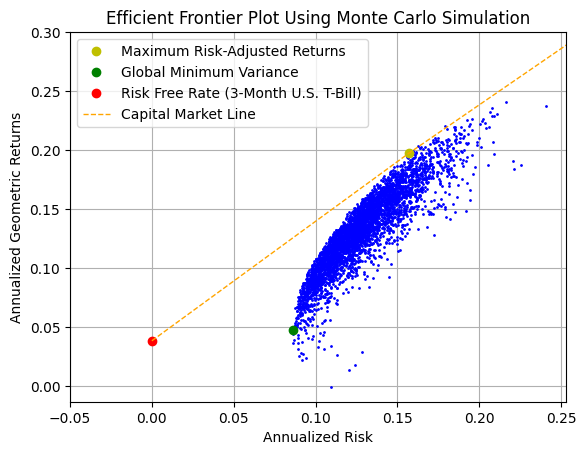

In [70]:
trials = 4000
asset_returns = daily_log_returns.values # convert log returns to arithmetic

# initialize variables for best sharpe
best_sharpe = -np.inf
b_sharpe_returns = 0
b_sharpe_risk = 0
best_weights = []

# initialize variables for global minimum variance (risk)
min_risk = np.inf
return_min_risk = 0
sharpe_min_risk = 0
min_risk_weights = []

for _ in range(trials):
    
    # create random weights
    nums = np.random.random((5, 1))

    weights = nums / nums.sum()
    
    # dot product for portfolio value
    portfolio_returns = asset_returns @ weights

    # find return
    annualized_returns = portfolio_returns.mean() * 252

    # find risk
    annualized_risk = portfolio_returns.std() * np.sqrt(252) # risk scales by sqrt(days)

    #find sharpe
    sharpe = annualized_returns / annualized_risk

    # save best sharpe
    if sharpe > best_sharpe:
        best_sharpe = sharpe
        b_sharpe_returns = annualized_returns
        b_sharpe_risk = annualized_risk
        best_weights = weights

    # save min risk
    if annualized_risk < min_risk:
        min_risk = annualized_risk
        return_min_risk = annualized_returns
        sharpe_min_risk = sharpe
        min_risk_weights = weights

    # plot point
    plt.plot(annualized_risk, annualized_returns, "bo", ms=1);

# plot efficient frontier

plt.plot(b_sharpe_risk, b_sharpe_returns, "yo", label="Maximum Risk-Adjusted Returns")
plt.plot(min_risk, return_min_risk, "go", label="Global Minimum Variance")
plt.plot(0, 0.0385, "ro", label="Risk Free Rate (3-Month U.S. T-Bill)")
plt.xlim(left=-0.05)
plt.ylim(top=0.3)

# plot capital market line
cml_sharpe = (b_sharpe_returns - 0.0385) / b_sharpe_risk # to extend line
x = [0, b_sharpe_risk, cml_sharpe]
y = [0.0385, b_sharpe_returns, cml_sharpe]
plt.plot(x, y, "--", linewidth=1, color="orange", label="Capital Market Line")

plt.title("Efficient Frontier Plot Using Monte Carlo Simulation")
plt.xlabel("Annualized Risk")
plt.ylabel("Annualized Geometric Returns")

plt.legend()
plt.grid(True)




In [57]:
print("== Portfolio With the Best Risk-Adjusted Return ==")
print(f"Tickers: {tickers}")
print(f"Weights: {np.round(best_weights.T, 2)}")
print(f"Sharpe Ratio: {best_sharpe:.2f}")
print(f"Average Annual Geometric Returns: {b_sharpe_returns:.2%}")
print(f"Average Annual Risk: {b_sharpe_risk:.2%}")

print()

print("== Portfolio with Global Minimum Variance ==")
print(f"Tickers: {tickers}")
print(f"Weights: {np.round(weights.T, 2)}")
print(f"Sharpe Ratio: {sharpe_min_risk:.2f}")
print(f"Average Annual Geometric Returns: {return_min_risk:.2%}")
print(f"Average Annual Risk: {min_risk:.2%}")

== Portfolio With the Best Risk-Adjusted Return ==
Tickers: ['GOOG', 'IAU', 'BTAL', 'LLY', 'VWO']
Weights: [[0.07 0.23 0.43 0.27 0.01]]
Sharpe Ratio: 1.26
Average Annual Geometric Returns: 17.53%
Average Annual Risk: 13.90%

== Portfolio with Global Minimum Variance ==
Tickers: ['GOOG', 'IAU', 'BTAL', 'LLY', 'VWO']
Weights: [[0.   0.34 0.38 0.17 0.1 ]]
Sharpe Ratio: 0.57
Average Annual Geometric Returns: 4.91%
Average Annual Risk: 8.60%
